# 📈 04 — Modelo de Previsão de Demanda

In [1]:
import warnings, pickle, os, sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("Imports OK")


/home/vinic/Documentos/Projetos/LH_Nautical/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Imports OK


## 1 · Leitura do banco SQLite

In [2]:
DB_PATH = '/home/vinic/Documentos/Projetos/LH_Nautical/datasets/nautical.db'

conn = sqlite3.connect(DB_PATH)

df_vendas   = pd.read_sql("SELECT * FROM vendas",   conn, parse_dates=['sale_date'])
df_produtos = pd.read_sql("SELECT * FROM produtos", conn)

conn.close()

print(f"vendas   : {df_vendas.shape[0]:,} linhas | sale_date: {df_vendas['sale_date'].dtype}")
print(f"produtos : {df_produtos.shape[0]} linhas  | categorias: {df_produtos['category'].unique().tolist()}")
print(f"Período  : {df_vendas['sale_date'].min().date()} → {df_vendas['sale_date'].max().date()}")


vendas   : 9,895 linhas | sale_date: datetime64[us]
produtos : 157 linhas  | categorias: ['ELETRONICOS', 'PROPULSAO', 'ANCORAGEM']
Período  : 2023-01-01 → 2024-12-31


## 2 · Agregação mensal

In [3]:
# Primeiro dia do mês como chave temporal
df_vendas['mes'] = df_vendas['sale_date'].dt.to_period('M').dt.to_timestamp()

# Juntar com produtos para ter nome e categoria
vendas = df_vendas.merge(
    df_produtos[['code', 'name', 'category']],
    left_on='id_product', right_on='code', how='left'
)

# Série mensal por PRODUTO
mensal_prod = (
    vendas.groupby(['id_product', 'name', 'category', 'mes'])['qtd']
    .sum()
    .reset_index()
    .rename(columns={'mes': 'ds', 'qtd': 'y'})
)

# Série mensal por CATEGORIA
mensal_cat = (
    vendas.groupby(['category', 'mes'])['qtd']
    .sum()
    .reset_index()
    .rename(columns={'mes': 'ds', 'qtd': 'y'})
)

print("Meses disponíveis:", mensal_prod['ds'].nunique())
print("\nVendas por categoria:")
print(mensal_cat.groupby('category')['y'].sum().to_string())


Meses disponíveis: 24

Vendas por categoria:
category
ANCORAGEM      28802
ELETRONICOS    27099
PROPULSAO      27036


## 3 · Seleção dos produtos para treino

In [4]:
# Top 3 produtos por volume total, com ao menos 18 meses de histórico
volume = (
    mensal_prod.groupby(['id_product', 'name', 'category'])
    .agg(total_qtd=('y', 'sum'), n_meses=('ds', 'nunique'))
    .reset_index()
    .sort_values('total_qtd', ascending=False)
)

produtos_sel = volume[volume['n_meses'] >= 18].head(3)
print("Produtos selecionados:")
print(produtos_sel[['id_product', 'name', 'category', 'total_qtd', 'n_meses']].to_string(index=False))

categorias_treino = mensal_cat['category'].unique().tolist()
print(f"\nCategorias para treino: {categorias_treino}")


Produtos selecionados:
 id_product                                   name  category  total_qtd  n_meses
         62      Motor Diesel Yanmar Velocity 37HP PROPULSAO       1792       23
        145        Boia de Arqueamento Delta Nexus ANCORAGEM       1689       23
        127 Cabo de Nylon Delta Velocity Core Mako ANCORAGEM       1292       24

Categorias para treino: ['ANCORAGEM', 'ELETRONICOS', 'PROPULSAO']


## 4 · Treinamento dos modelos com Prophet

In [5]:
def serie_completa(df: pd.DataFrame) -> pd.DataFrame:
    """Preenche meses sem venda com 0 para manter série contínua."""
    rng  = pd.date_range(df['ds'].min(), df['ds'].max(), freq='MS')
    return (pd.DataFrame({'ds': rng})
              .merge(df[['ds','y']], on='ds', how='left')
              .fillna(0))


def treinar(serie: pd.DataFrame, label: str) -> dict:
    """Treina Prophet, avalia com holdout dos últimos 6 meses e retorna pacote."""
    serie = serie_completa(serie).sort_values('ds').reset_index(drop=True)

    # Modelo final (série completa)
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.15,
        seasonality_prior_scale=10,
        interval_width=0.90,
    )
    m.fit(serie)
    future   = m.make_future_dataframe(periods=3, freq='MS')
    forecast = m.predict(future)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = forecast[col].clip(lower=0)

    # Avaliação: holdout últimos 6 meses
    treino = serie.iloc[:-6]
    teste  = serie.iloc[-6:]
    m2 = Prophet(
        yearly_seasonality=True, weekly_seasonality=False,
        daily_seasonality=False, seasonality_mode='multiplicative',
        changepoint_prior_scale=0.15, seasonality_prior_scale=10,
    )
    m2.fit(treino)
    pred = m2.predict(teste[['ds']])
    pred['yhat'] = pred['yhat'].clip(lower=0)

    mae  = mean_absolute_error(teste['y'], pred['yhat'])
    rmse = np.sqrt(mean_squared_error(teste['y'], pred['yhat']))
    mape = (mae / teste['y'].mean() * 100) if teste['y'].mean() > 0 else float('nan')

    print(f"  {'─'*52}")
    print(f"  {label}")
    print(f"    MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%")

    return dict(label=label, model=m, serie=serie,
                forecast=forecast, mae=mae, rmse=rmse, mape=mape)


# Treinar produtos
print("\nPRODUTOS")
res_prod = {}
for _, row in produtos_sel.iterrows():
    serie = mensal_prod[mensal_prod['id_product'] == row['id_product']][['ds','y']].copy()
    res_prod[row['id_product']] = treinar(serie, f"{row['name']}  [{row['category']}]")

# Treinar categorias
print("\nCATEGORIAS")
res_cat = {}
for cat in categorias_treino:
    serie = mensal_cat[mensal_cat['category'] == cat][['ds','y']].copy()
    res_cat[cat] = treinar(serie, f"Categoria · {cat}")

print("\nTreino concluído!")



PRODUTOS


22:47:39 - cmdstanpy - INFO - Chain [1] start processing
22:48:35 - cmdstanpy - INFO - Chain [1] done processing
22:48:35 - cmdstanpy - INFO - Chain [1] start processing
22:49:19 - cmdstanpy - INFO - Chain [1] done processing
22:49:19 - cmdstanpy - INFO - Chain [1] start processing


  ────────────────────────────────────────────────────
  Motor Diesel Yanmar Velocity 37HP  [PROPULSAO]
    MAE=206.5  RMSE=373.2  MAPE=267.1%


22:50:16 - cmdstanpy - INFO - Chain [1] done processing
22:50:16 - cmdstanpy - INFO - Chain [1] start processing
22:50:59 - cmdstanpy - INFO - Chain [1] done processing
22:50:59 - cmdstanpy - INFO - Chain [1] start processing


  ────────────────────────────────────────────────────
  Boia de Arqueamento Delta Nexus  [ANCORAGEM]
    MAE=89.2  RMSE=120.5  MAPE=135.2%


...

  ────────────────────────────────────────────────────
  Categoria · ANCORAGEM
    MAE=2051.1  RMSE=2749.8  MAPE=183.5%


22:55:18 - cmdstanpy - INFO - Chain [1] done processing
22:55:18 - cmdstanpy - INFO - Chain [1] start processing
22:56:03 - cmdstanpy - INFO - Chain [1] done processing
22:56:03 - cmdstanpy - INFO - Chain [1] start processing


  ────────────────────────────────────────────────────
  Categoria · ELETRONICOS
    MAE=716.5  RMSE=847.8  MAPE=61.9%


22:56:58 - cmdstanpy - INFO - Chain [1] done processing
22:56:58 - cmdstanpy - INFO - Chain [1] start processing
22:57:43 - cmdstanpy - INFO - Chain [1] done processing


  ────────────────────────────────────────────────────
  Categoria · PROPULSAO
    MAE=895.8  RMSE=1028.9  MAPE=74.6%

Treino concluído!


## 5 · Métricas de avaliação (holdout 6 meses)

In [6]:
rows = [
    {'Série': r['label'], 'MAE': round(r['mae'],1),
     'RMSE': round(r['rmse'],1), 'MAPE (%)': round(r['mape'],1)}
    for r in list(res_prod.values()) + list(res_cat.values())
]
metricas = pd.DataFrame(rows)
metricas.index = range(1, len(metricas)+1)
metricas


,Série,MAE,RMSE,MAPE (%)
1,Motor Diesel Yanmar Velocity 37HP [PROPULSAO],206.5,373.2,267.1
2,Boia de Arqueamento Delta Nexus [ANCORAGEM],89.2,120.5,135.2
3,Cabo de Nylon Delta Velocity Core Mako [ANCOR...,70.0,86.6,156.8
4,Categoria · ANCORAGEM,2051.1,2749.8,183.5
5,Categoria · ELETRONICOS,716.5,847.8,61.9
6,Categoria · PROPULSAO,895.8,1028.9,74.6


## 6 · Gráficos — Histórico + Previsão 3 meses

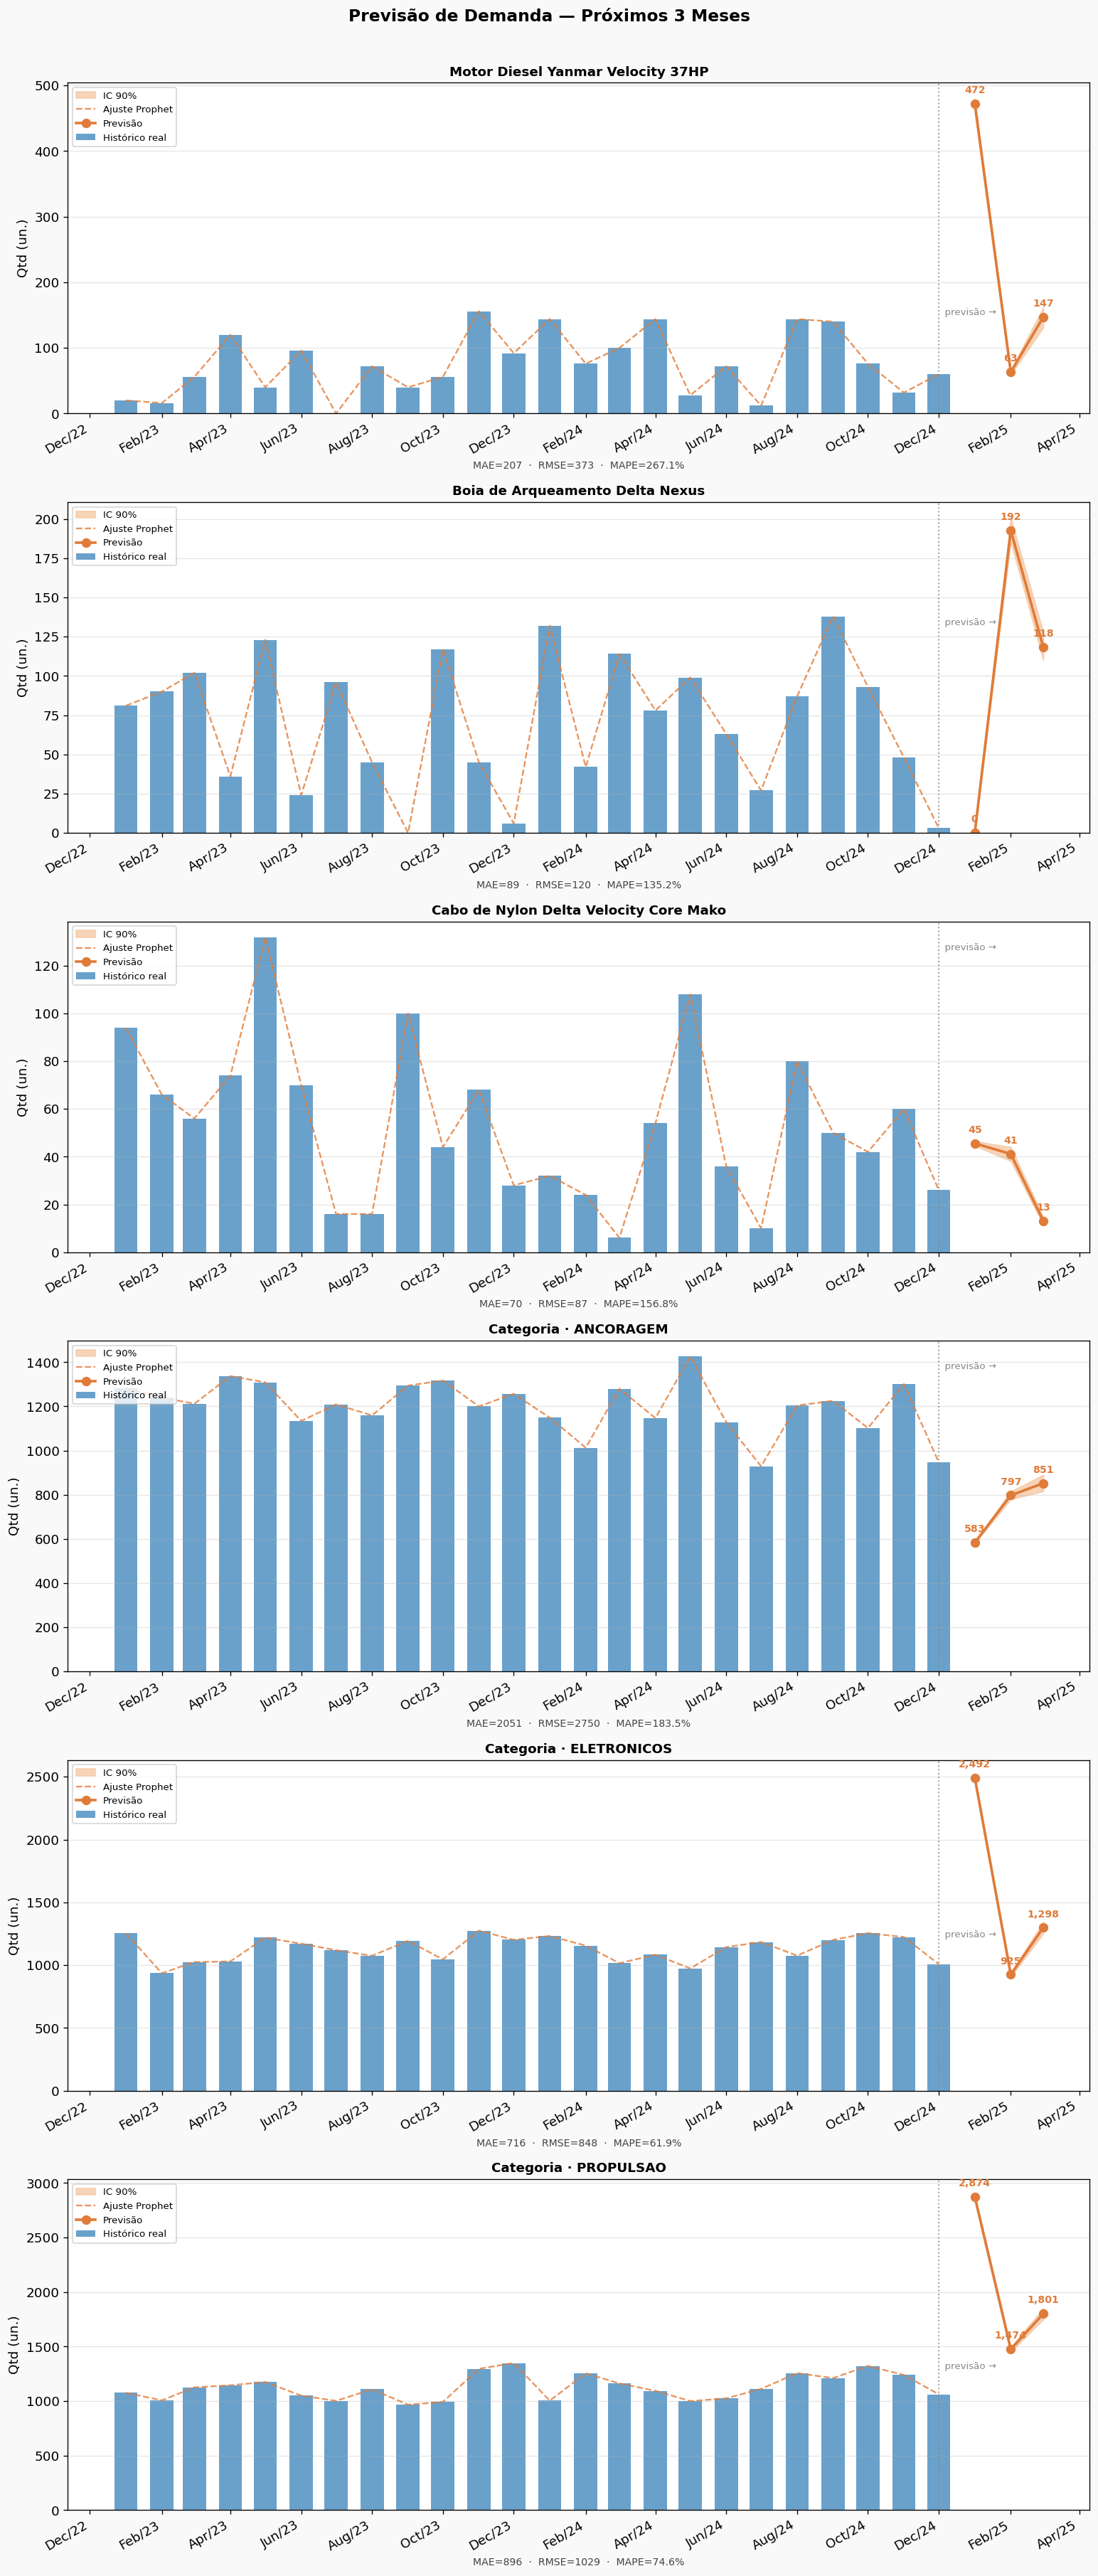


Gráfico salvo em previsao_demanda.png


In [7]:
COR_HIST = '#1a6faf'
COR_PREV = '#e07b39'
COR_BAND = '#f5c6a0'
COR_DIV  = '#888888'


def plot_serie(res: dict, ax: plt.Axes, titulo: str) -> None:
    serie    = res['serie']
    forecast = res['forecast']
    corte    = serie['ds'].max()
    ymax     = max(float(serie['y'].max()), 1.0)

    fut = forecast[forecast['ds'] > corte]
    his = forecast[forecast['ds'] <= corte]

    # Banda IC (futuro)
    ax.fill_between(fut['ds'], fut['yhat_lower'], fut['yhat_upper'],
                    color=COR_BAND, alpha=0.75, label='IC 90%')
    # Ajuste histórico
    ax.plot(his['ds'], his['yhat'], '--', color=COR_PREV,
            lw=1.4, alpha=0.8, label='Ajuste Prophet')
    # Previsão futura
    ax.plot(fut['ds'], fut['yhat'], 'o-', color=COR_PREV,
            lw=2.2, ms=7, label='Previsão')
    # Histórico real
    ax.bar(serie['ds'], serie['y'], width=20,
           color=COR_HIST, alpha=0.65, label='Histórico real')
    # Linha de corte
    ax.axvline(corte, color=COR_DIV, lw=1.2, ls=':', alpha=0.8)
    ax.text(corte, ymax * 0.96, '  previsão →', fontsize=8, color=COR_DIV)

    # Rótulos de valor nas barras futuras
    for _, r in fut.iterrows():
        v = max(0.0, float(r['yhat']))
        ax.annotate(f"{int(v):,}", xy=(r['ds'], v),
                    xytext=(0, 9), textcoords='offset points',
                    ha='center', fontsize=8.5, fontweight='bold', color=COR_PREV)

    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=6)
    ax.set_ylabel('Qtd (un.)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_xlabel(
        f"MAE={res['mae']:.0f}  ·  RMSE={res['rmse']:.0f}  ·  MAPE={res['mape']:.1f}%",
        fontsize=8.5, color='#444'
    )
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)


total = len(res_prod) + len(res_cat)
fig, axes = plt.subplots(total, 1, figsize=(13, 5 * total))
fig.suptitle('Previsão de Demanda — Próximos 3 Meses',
             fontsize=14, fontweight='bold', y=1.005)
fig.patch.set_facecolor('#f9f9f9')

idx = 0
for pid, res in res_prod.items():
    nome = res['label'].split('  [')[0][:55]
    plot_serie(res, axes[idx], nome)
    idx += 1

for cat, res in res_cat.items():
    plot_serie(res, axes[idx], f'Categoria · {cat}')
    idx += 1

plt.tight_layout()
plt.savefig('/home/vinic/Documentos/Projetos/LH_Nautical/figures/not04/previsao_demanda.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nGráfico salvo em previsao_demanda.png")


## 7 · Previsão — próximos 3 meses

In [8]:
linhas = []
for pid, res in res_prod.items():
    nome = res['label'].split('  [')[0][:45]
    fut  = res['forecast'][res['forecast']['ds'] > res['serie']['ds'].max()].head(3)
    for _, r in fut.iterrows():
        linhas.append({'Tipo': 'Produto', 'Série': nome,
                       'Mês': r['ds'].strftime('%b/%Y'),
                       'Prev.(un.)': max(0, round(float(r['yhat']))),
                       'IC Inf.':    max(0, round(float(r['yhat_lower']))),
                       'IC Sup.':    max(0, round(float(r['yhat_upper'])))})

for cat, res in res_cat.items():
    fut = res['forecast'][res['forecast']['ds'] > res['serie']['ds'].max()].head(3)
    for _, r in fut.iterrows():
        linhas.append({'Tipo': 'Categoria', 'Série': cat,
                       'Mês': r['ds'].strftime('%b/%Y'),
                       'Prev.(un.)': max(0, round(float(r['yhat']))),
                       'IC Inf.':    max(0, round(float(r['yhat_lower']))),
                       'IC Sup.':    max(0, round(float(r['yhat_upper'])))})

prev_df = pd.DataFrame(linhas)
prev_df.index = range(1, len(prev_df)+1)
prev_df


,Tipo,Série,Mês,Prev.(un.),IC Inf.,IC Sup.
1,Produto,Motor Diesel Yanmar Velocity 37HP,Jan/2025,472,463,480
2,Produto,Motor Diesel Yanmar Velocity 37HP,Feb/2025,63,59,67
3,Produto,Motor Diesel Yanmar Velocity 37HP,Mar/2025,147,131,162
4,Produto,Boia de Arqueamento Delta Nexus,Jan/2025,0,0,0
5,Produto,Boia de Arqueamento Delta Nexus,Feb/2025,193,185,201
6,Produto,Boia de Arqueamento Delta Nexus,Mar/2025,118,110,128
7,Produto,Cabo de Nylon Delta Velocity Core Mako,Jan/2025,46,45,47
8,Produto,Cabo de Nylon Delta Velocity Core Mako,Feb/2025,41,38,44
9,Produto,Cabo de Nylon Delta Velocity Core Mako,Mar/2025,13,11,15
10,Categoria,ANCORAGEM,Jan/2025,583,579,587


## 8 · Salvar modelo

In [9]:
MODEL_DIR = '/home/vinic/Documentos/Projetos/LH_Nautical/models'
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, 'modelo_previsao.pkl')

pacote = {
    'versao':       '1.0',
    'data_treino':  pd.Timestamp.today().strftime('%Y-%m-%d'),
    'db_origem':    DB_PATH,
    'resultados_produtos':   {
        pid: {k: r[k] for k in ('model','serie','forecast','label','mae','rmse','mape')}
        for pid, r in res_prod.items()
    },
    'resultados_categorias': {
        cat: {k: r[k] for k in ('model','serie','forecast','label','mae','rmse','mape')}
        for cat, r in res_cat.items()
    },
    'produtos_meta': produtos_sel.to_dict('records'),
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(pacote, f)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"   Modelo salvo em: {MODEL_PATH}  ({size_kb:.0f} KB)")
print(f"   Produtos  : {len(pacote['resultados_produtos'])}")
print(f"   Categorias: {len(pacote['resultados_categorias'])}")
print(f"   Treinado  : {pacote['data_treino']}")


   Modelo salvo em: /home/vinic/Documentos/Projetos/LH_Nautical/models/modelo_previsao.pkl  (82 KB)
   Produtos  : 3
   Categorias: 3
   Treinado  : 2026-03-23
